# 03 — Preditores do ENDURECIMENTO (Cap. 6.3)

**Modelo:** OLS + Regressão ordinal

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
df = pd.read_csv('../data/processed/corpus_dataset.csv')
INDICATORS = ['desincorporacao','rigidez_postural','dessexualizacao','uniformizacao_facial','heraldizacao','enquadramento_arquitetonico','apagamento_narrativo','monocromatizacao','serialidade','inscricao_estatal']
INDICATOR_LABELS = {'desincorporacao':'Desincorporação','rigidez_postural':'Rigidez postural','dessexualizacao':'Dessexualização','uniformizacao_facial':'Uniformização facial','heraldizacao':'Heraldicização','enquadramento_arquitetonico':'Enquadramento arq.','apagamento_narrativo':'Apagamento narrativo','monocromatizacao':'Monocromatização','serialidade':'Serialidade','inscricao_estatal':'Inscrição estatal'}

print("="*60)
print("  OLS: ENDURECIMENTO ~ regime")
print("="*60)
X = pd.get_dummies(df['regime_iconocratico'], drop_first=True, dtype=float)
X = sm.add_constant(X)
y = df['purificacao_composto']
model = sm.OLS(y, X).fit()
print(model.summary2().tables[1].to_string())
print(f"R2 = {model.rsquared:.3f}, Adj. R2 = {model.rsquared_adj:.3f}")

  OLS: ENDURECIMENTO ~ regime
              Coef.  Std.Err.          t         P>|t|    [0.025    0.975]
const      1.101754  0.070492  15.629528  1.237125e-27  0.961751  1.241757
militar    0.428246  0.182464   2.347019  2.106952e-02  0.065857  0.790634
normativo  0.676817  0.122820   5.510638  3.236832e-07  0.432886  0.920748
R2 = 0.256, Adj. R2 = 0.240


## 3.2 OLS com regime + suporte

In [2]:
print("="*60)
print("  OLS: ENDURECIMENTO ~ regime + medium")
print("="*60)
predictors = pd.get_dummies(df['regime_iconocratico'], drop_first=True, dtype=float)
med_dummies = pd.get_dummies(df['medium_norm'], prefix='med', drop_first=True, dtype=float)
med_cols = [c for c in med_dummies.columns if med_dummies[c].sum() >= 5]
predictors = pd.concat([predictors, med_dummies[med_cols]], axis=1)
X_full = sm.add_constant(predictors)
model_full = sm.OLS(df['purificacao_composto'], X_full).fit()
print(model_full.summary2().tables[1].to_string())
print(f"R2 = {model_full.rsquared:.3f}, Adj. R2 = {model_full.rsquared_adj:.3f}")

  OLS: ENDURECIMENTO ~ regime + medium
                        Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
const                0.992332  0.147005  6.750347  1.574243e-09  0.700144  1.284519
militar              0.361213  0.170172  2.122635  3.662590e-02  0.022978  0.699448
normativo            0.753923  0.122217  6.168744  2.109524e-08  0.511004  0.996842
med_Fotografia       0.148284  0.221641  0.669028  5.052493e-01 -0.292251  0.588818
med_Gravura          0.227399  0.179350  1.267907  2.082139e-01 -0.129078  0.583875
med_Gravura/Estampe -0.116568  0.157947 -0.738018  4.624893e-01 -0.430504  0.197369
med_Outro            0.485762  0.170212  2.853861  5.397329e-03  0.147447  0.824078
med_Pintura/Desenho -0.349072  0.219722 -1.588702  1.157555e-01 -0.785793  0.087648
R2 = 0.431, Adj. R2 = 0.385


## 3.3 Dessexualização como preditor

  Correlação de cada indicador com o composto
  desincorporacao                rho = 0.805  p = 0.0000 ***
  rigidez_postural               rho = 0.843  p = 0.0000 ***
  dessexualizacao                rho = 0.788  p = 0.0000 ***
  uniformizacao_facial           rho = 0.815  p = 0.0000 ***
  heraldizacao                   rho = 0.793  p = 0.0000 ***
  enquadramento_arquitetonico    rho = 0.787  p = 0.0000 ***
  apagamento_narrativo           rho = 0.758  p = 0.0000 ***
  monocromatizacao               rho = 0.322  p = 0.0015 **
  serialidade                    rho = 0.447  p = 0.0000 ***
  inscricao_estatal              rho = 0.695  p = 0.0000 ***


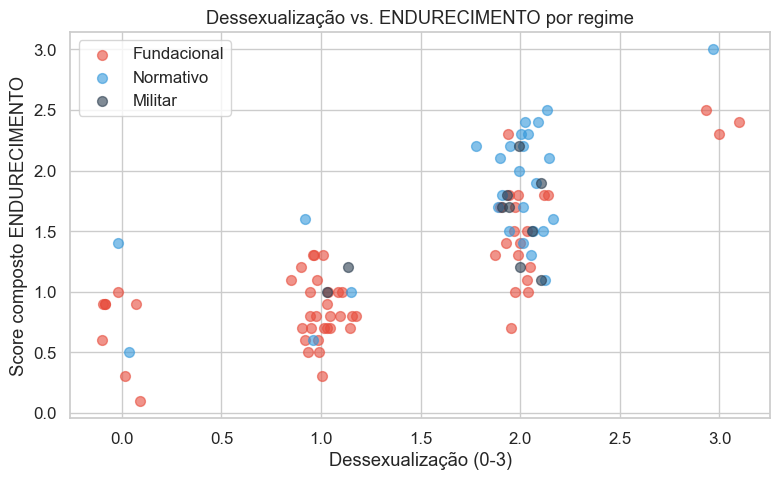

In [3]:
print("="*60)
print("  Correlação de cada indicador com o composto")
print("="*60)
for ind in INDICATORS:
    rho, p = spearmanr(df[ind], df['purificacao_composto'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {ind:<30s} rho = {rho:.3f}  p = {p:.4f} {sig}")

fig, ax = plt.subplots(figsize=(8, 5))
palette = {'fundacional': '#e74c3c', 'normativo': '#3498db', 'militar': '#2c3e50'}
for regime in ['fundacional', 'normativo', 'militar']:
    sub = df[df.regime_iconocratico == regime]
    ax.scatter(sub['dessexualizacao'] + np.random.normal(0, 0.08, len(sub)),
              sub['purificacao_composto'], alpha=0.6, label=regime.capitalize(), color=palette[regime], s=50)
ax.set_xlabel('Dessexualização (0-3)')
ax.set_ylabel('Score composto ENDURECIMENTO')
ax.set_title('Dessexualização vs. ENDURECIMENTO por regime')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_07_dessex_vs_endurec.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Importância relativa dos indicadores

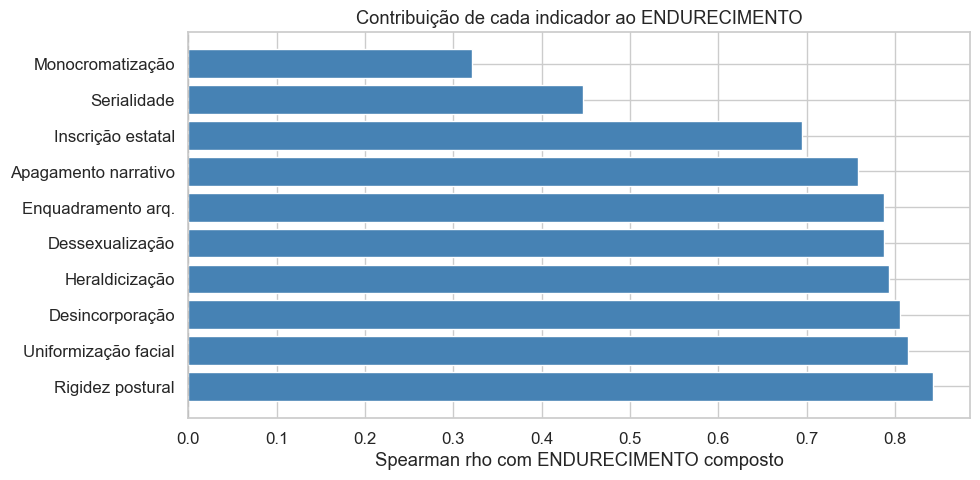

In [4]:
rhos = []
for ind in INDICATORS:
    rho, _ = spearmanr(df[ind], df['purificacao_composto'])
    rhos.append((INDICATOR_LABELS[ind], rho))
rhos.sort(key=lambda x: x[1], reverse=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([r[0] for r in rhos], [r[1] for r in rhos], color='steelblue')
ax.set_xlabel('Spearman rho com ENDURECIMENTO composto')
ax.set_title('Contribuição de cada indicador ao ENDURECIMENTO')
ax.axvline(0, color='grey', ls='--')
plt.tight_layout()
plt.savefig('../data/processed/fig_08_indicator_importance.png', dpi=150, bbox_inches='tight')
plt.show()